In [1]:
from modules.train import train_model
from modules.model import TumorClassifier, TumorClassifierMBConv
from modules.hybrid_model import EfficientNetCBAMClassifier
from modules.transforms import train_transform, val_transform, test_transform
from modules.metrics import evaluate_and_report
from modules.train2 import train_model2, train_model3
import torch
from torchvision import datasets
from torch.utils.data import random_split, ConcatDataset, DataLoader

/data/students/joshua_c/dev/ai231-group/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetCBAMClassifier(num_classes=4)
model = model.to(device)

Unexpected keys (bn2.bias, bn2.num_batches_tracked, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [3]:
# Load dataset using ImageFolder
train_dataset = datasets.ImageFolder(root="brain_tumor_dataset/Training", transform=train_transform())
test_dataset = datasets.ImageFolder(root="brain_tumor_dataset/Testing", transform=train_transform())
classes = test_dataset.classes
full_dataset = ConcatDataset([train_dataset, test_dataset])

train_dataset, test_dataset = random_split(
    full_dataset,
    [0.7, 0.3],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
train_model3(
    model,
    train_dataset,
    batch_size=32,
    epochs=30,
    lr=0.0003,
    save_path="./training_data/hybrid_model.pth",   # save the best model weights
    use_sampler=True,             # if your classes are imbalanced
    scheduler_type="steplr",       # or "cosine"
    use_mixup=True,               # optional: if you want stronger augmentation
    fine_tune_at_epoch=10,          # start fine-tuning deeper layers at epoch 5
    hybrid=True
)

Epoch 1/20 - Loss: 35.4205 - Train Acc: 0.3479 - Val Acc: 0.5274


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetCBAMClassifier()
model.load_state_dict(torch.load("./training_data/hybrid_model.pth"))
model = model.to(device)
model.eval()  # Set the model to evaluation mode

Unexpected keys (bn2.bias, bn2.num_batches_tracked, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
/tmp/ipykernel_911446/2131296180.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for 

EfficientNetCBAMClassifier(
  (backbone): EfficientNetFeatures(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )

In [ ]:
test_dataset.dataset.transform = val_transform()
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


=== Classification Report ===
                  precision    recall  f1-score   support

    glioma_tumor       0.99      0.88      0.93       284
meningioma_tumor       0.87      0.89      0.88       260
        no_tumor       0.88      0.99      0.93       156
 pituitary_tumor       0.94      0.95      0.95       279

        accuracy                           0.92       979
       macro avg       0.92      0.93      0.92       979
    weighted avg       0.93      0.92      0.92       979


=== Test Accuracy: 92.24% ===


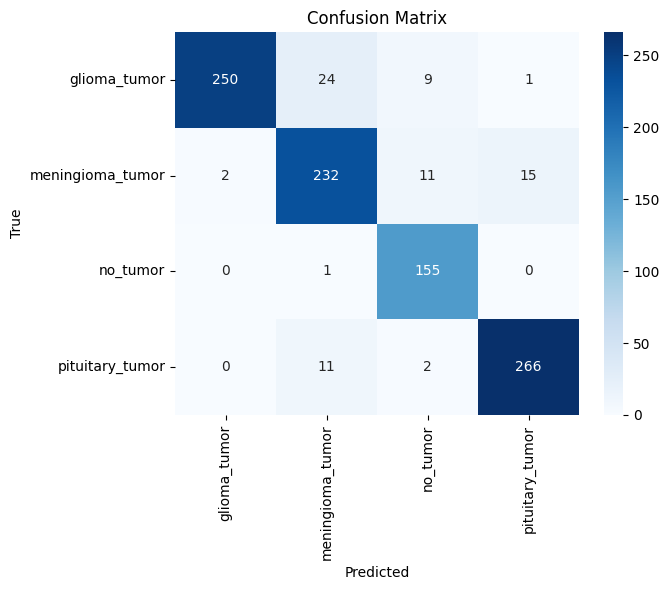

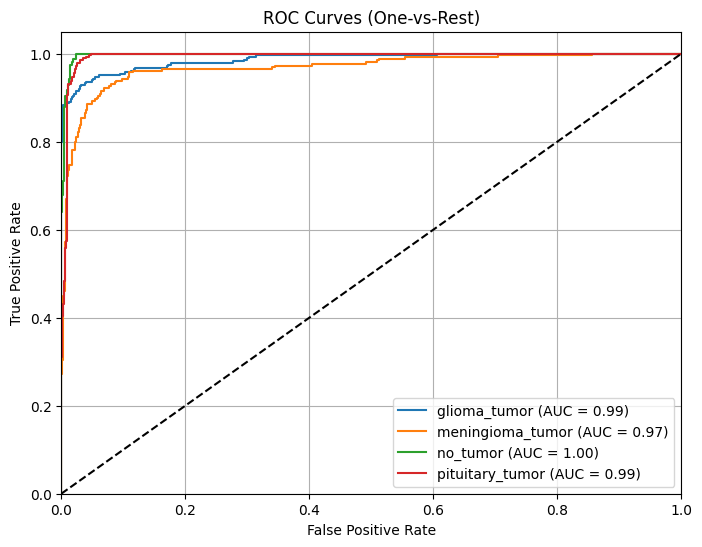

(array([2, 0, 1, 3, 1, 3, 0, 1, 1, 3, 1, 3, 1, 2, 2, 1, 3, 1, 2, 1, 1, 3,
        0, 3, 3, 3, 0, 1, 1, 0, 1, 2, 0, 1, 3, 0, 3, 3, 1, 3, 3, 0, 0, 1,
        1, 3, 1, 0, 0, 2, 2, 0, 3, 3, 1, 3, 3, 0, 3, 3, 2, 3, 0, 0, 2, 2,
        1, 3, 0, 0, 2, 1, 1, 1, 3, 3, 1, 3, 3, 2, 2, 1, 2, 1, 0, 3, 2, 1,
        3, 1, 3, 0, 0, 3, 3, 2, 3, 3, 0, 0, 1, 0, 1, 3, 0, 0, 0, 1, 0, 1,
        3, 1, 1, 0, 2, 2, 0, 0, 2, 1, 3, 1, 3, 3, 3, 3, 1, 2, 1, 1, 3, 0,
        0, 3, 3, 0, 3, 3, 3, 2, 1, 0, 1, 3, 2, 1, 3, 0, 2, 3, 3, 0, 3, 3,
        3, 1, 3, 1, 2, 0, 3, 2, 1, 1, 0, 1, 1, 3, 0, 1, 3, 3, 2, 1, 1, 2,
        1, 0, 0, 1, 0, 0, 2, 0, 0, 1, 2, 1, 3, 1, 1, 0, 1, 0, 2, 1, 1, 1,
        0, 1, 3, 1, 0, 2, 1, 3, 0, 1, 0, 0, 0, 3, 2, 0, 1, 0, 3, 3, 2, 2,
        0, 3, 1, 3, 3, 2, 1, 0, 0, 2, 2, 2, 3, 3, 3, 0, 3, 0, 3, 1, 3, 1,
        1, 3, 1, 0, 0, 3, 2, 3, 3, 3, 1, 3, 2, 2, 0, 1, 0, 2, 2, 2, 0, 0,
        2, 2, 3, 0, 3, 0, 2, 2, 1, 1, 3, 0, 3, 3, 3, 0, 0, 3, 0, 0, 0, 0,
        2, 2, 1, 0, 2, 0, 3, 3, 1, 0, 

In [ ]:
evaluate_and_report(
    model,
    test_loader,
    device,
    classes,
)